In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
a0 = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/annot/gencode.vM32.annotation.gtf.gz'
dfg = pd.read_csv(a0, skiprows=5, sep='\t', header=None)
dfg = dfg[dfg[2]=='gene']
dfg

,0,1,2,3,4,5,6,7,8
0,chr1,HAVANA,gene,3143476,3144545,.,+,.,"gene_id ""ENSMUSG00000102693.2""; gene_type ""TEC..."
3,chr1,ENSEMBL,gene,3172239,3172348,.,+,.,"gene_id ""ENSMUSG00000064842.3""; gene_type ""snR..."
6,chr1,HAVANA,gene,3276124,3741721,.,-,.,"gene_id ""ENSMUSG00000051951.6""; gene_type ""pro..."
24,chr1,HAVANA,gene,3322980,3323459,.,+,.,"gene_id ""ENSMUSG00000102851.2""; gene_type ""pro..."
27,chr1,HAVANA,gene,3435954,3438772,.,-,.,"gene_id ""ENSMUSG00000103377.2""; gene_type ""TEC..."
...,...,...,...,...,...,...,...,...,...
1903921,chrM,ENSEMBL,gene,13552,14070,.,-,.,"gene_id ""ENSMUSG00000064368.1""; gene_type ""pro..."
1903928,chrM,ENSEMBL,gene,14071,14139,.,-,.,"gene_id ""ENSMUSG00000064369.1""; gene_type ""Mt_..."
1903931,chrM,ENSEMBL,gene,14145,15288,.,+,.,"gene_id ""ENSMUSG00000064370.1""; gene_type ""pro..."
1903936,chrM,ENSEMBL,gene,15289,15355,.,+,.,"gene_id ""ENSMUSG00000064371.1""; gene_type ""Mt_..."


In [3]:
gids = dfg[8].str.split(';').apply(lambda x: x[0])
gnms = dfg[8].str.split(';').apply(lambda x: x[2])


gids = gids.str.split('"').apply(lambda x: x[-2])
gnms = gnms.str.split('"').apply(lambda x: x[-2])
gids = gids.str.split('.').apply(lambda x: x[0])
gids

0          ENSMUSG00000102693
3          ENSMUSG00000064842
6          ENSMUSG00000051951
24         ENSMUSG00000102851
27         ENSMUSG00000103377
                  ...        
1903921    ENSMUSG00000064368
1903928    ENSMUSG00000064369
1903931    ENSMUSG00000064370
1903936    ENSMUSG00000064371
1903939    ENSMUSG00000064372
Name: 8, Length: 56953, dtype: object

In [4]:
gn2id = pd.Series(gids.values, index=gnms.values)
gn2id

4933401J01Rik    ENSMUSG00000102693
Gm26206          ENSMUSG00000064842
Xkr4             ENSMUSG00000051951
Gm18956          ENSMUSG00000102851
Gm37180          ENSMUSG00000103377
                        ...        
mt-Nd6           ENSMUSG00000064368
mt-Te            ENSMUSG00000064369
mt-Cytb          ENSMUSG00000064370
mt-Tt            ENSMUSG00000064371
mt-Tp            ENSMUSG00000064372
Length: 56953, dtype: object

In [5]:
%%time
f0   = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_yao23/cell_metadata_with_cluster_annotation_l23_vis_ptlp.csv'
f1 = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_yao23/WMB-10Xv3-VIS-raw.h5ad'

CPU times: user 6 µs, sys: 0 ns, total: 6 µs
Wall time: 10.7 µs


In [6]:
meta = pd.read_csv(f0)
meta

,Unnamed: 0,cell_label,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,...,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,donor_name,external_donor_name,cycle,assay,sex
0,29781,GCACATAGTTTACGAC-447_B06,GCACATAGTTTACGAC,447_B06,L8TX_201204_01_A02,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,VIS-PTLp,...,#E9530F,#5C6899,#1F6624,6,#26AEFF,554815,554815,Light,10Xv3,F
1,29782,AGACAGGTCTGCGATA-447_B06,AGACAGGTCTGCGATA,447_B06,L8TX_201204_01_A02,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,VIS-PTLp,...,#E9530F,#5C6899,#1F6624,6,#26AEFF,554815,554815,Light,10Xv3,F
2,29783,CTAGACATCGATGCAT-447_B06,CTAGACATCGATGCAT,447_B06,L8TX_201204_01_A02,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,VIS-PTLp,...,#E9530F,#5C6899,#43992E,6,#26AEFF,554815,554815,Light,10Xv3,F
3,29784,GGGCCATAGGCACTCC-447_B06,GGGCCATAGGCACTCC,447_B06,L8TX_201204_01_A02,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,VIS-PTLp,...,#E9530F,#5C6899,#43992E,6,#26AEFF,554815,554815,Light,10Xv3,F
4,29785,GCCTGTTTCTCAGTCC-447_B06,GCCTGTTTCTCAGTCC,447_B06,L8TX_201204_01_A02,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,VIS-PTLp,...,#E9530F,#5C6899,#43992E,6,#26AEFF,554815,554815,Light,10Xv3,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,37972,TGTACAGGTGTGGTCC-444_B04,TGTACAGGTGTGGTCC,444_B04,L8TX_201204_01_E01,WMB-10Xv3-Isocortex-2,cell,NaN,10Xv3,VIS-PTLp,...,#E9530F,#CC7A8F,#AA7ACC,6,#26AEFF,553680,553680,Dark,10Xv3,M
3796,37973,TGTGCGGAGCAGCGAT-444_B04,TGTGCGGAGCAGCGAT,444_B04,L8TX_201204_01_E01,WMB-10Xv3-Isocortex-2,cell,NaN,10Xv3,VIS-PTLp,...,#E9530F,#CC7A8F,#AA7ACC,6,#26AEFF,553680,553680,Dark,10Xv3,M
3797,37974,TGTTCATAGATGACCG-444_B04,TGTTCATAGATGACCG,444_B04,L8TX_201204_01_E01,WMB-10Xv3-Isocortex-2,cell,NaN,10Xv3,VIS-PTLp,...,#E9530F,#CC7A8F,#AA7ACC,6,#26AEFF,553680,553680,Dark,10Xv3,M
3798,37975,TTAGGGTGTGGAACAC-444_B04,TTAGGGTGTGGAACAC,444_B04,L8TX_201204_01_E01,WMB-10Xv3-Isocortex-2,cell,NaN,10Xv3,VIS-PTLp,...,#E9530F,#CC7A8F,#AA7ACC,6,#26AEFF,553680,553680,Dark,10Xv3,M


In [7]:
%%time
adata = sc.read(f1)
adata

CPU times: user 191 ms, sys: 361 ms, total: 552 ms
Wall time: 2.69 s


AnnData object with n_obs × n_vars = 3800 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label'

In [8]:
meta['cycle']=='Dark'
meta['cycle']=='Light'

0        True
1        True
2        True
3        True
4        True
        ...  
3795    False
3796    False
3797    False
3798    False
3799    False
Name: cycle, Length: 3800, dtype: bool

In [9]:
adata.X.data

array([91.,  2.,  3., ...,  9., 31., 11.], dtype=float32)

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Keep a copy of the full data before subsetting
adatasub = adata[:, adata.var.highly_variable]
adatasub


View of AnnData object with n_obs × n_vars = 3800 × 2760
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [11]:
adatasub.X.data

array([2.768821 , 0.283936 , 0.4004672, ..., 1.0423261, 1.8729426,
       1.0423261], dtype=float32)

In [12]:
sc.tl.pca(adata, svd_solver='arpack')

In [13]:
adata

AnnData object with n_obs × n_vars = 3800 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [14]:
pcs = adata.obsm['X_pca']
pcs.shape

(3800, 50)

In [15]:
adata_light = adata[meta['cycle']=='Light']
adata_dark  = adata[meta['cycle']=='Dark']

In [16]:
dfviz = pd.DataFrame(pcs[:,:5], index=adata.obs.index)
dfviz = dfviz.join(meta.set_index('cell_label'))

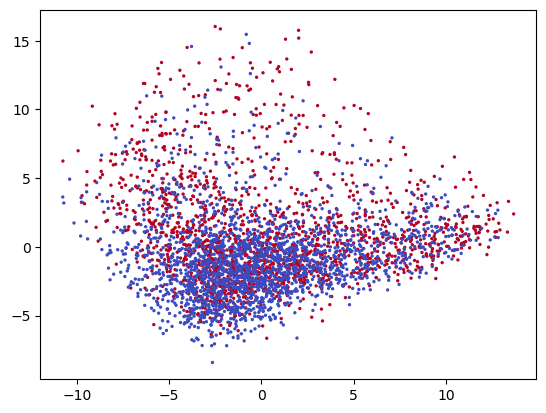

In [17]:
plt.scatter(pcs[:,0], pcs[:,1], c=(meta['cycle']=='Light').astype(int), s=2, cmap='coolwarm')

In [18]:
dfviz

,0,1,2,3,4,Unnamed: 0,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,...,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,donor_name,external_donor_name,cycle,assay,sex
cell_label,,,,,,,,,,,,,,,,,,,,,
GCACATAGTTTACGAC-447_B06,7.224776,0.668026,1.816755,-1.955094,-1.616947,29781,GCACATAGTTTACGAC,447_B06,L8TX_201204_01_A02,WMB-10Xv3-Isocortex-1,...,#E9530F,#5C6899,#1F6624,6,#26AEFF,554815,554815,Light,10Xv3,F
AGACAGGTCTGCGATA-447_B06,11.845337,1.451622,-0.397963,-0.255970,1.674722,29782,AGACAGGTCTGCGATA,447_B06,L8TX_201204_01_A02,WMB-10Xv3-Isocortex-1,...,#E9530F,#5C6899,#1F6624,6,#26AEFF,554815,554815,Light,10Xv3,F
CTAGACATCGATGCAT-447_B06,9.247663,-0.326622,0.466255,-2.381487,2.038427,29783,CTAGACATCGATGCAT,447_B06,L8TX_201204_01_A02,WMB-10Xv3-Isocortex-1,...,#E9530F,#5C6899,#43992E,6,#26AEFF,554815,554815,Light,10Xv3,F
GGGCCATAGGCACTCC-447_B06,10.882927,1.126700,-0.889798,-1.794773,0.123898,29784,GGGCCATAGGCACTCC,447_B06,L8TX_201204_01_A02,WMB-10Xv3-Isocortex-1,...,#E9530F,#5C6899,#43992E,6,#26AEFF,554815,554815,Light,10Xv3,F
GCCTGTTTCTCAGTCC-447_B06,13.673053,2.394252,-0.088929,-2.149352,3.366681,29785,GCCTGTTTCTCAGTCC,447_B06,L8TX_201204_01_A02,WMB-10Xv3-Isocortex-1,...,#E9530F,#5C6899,#43992E,6,#26AEFF,554815,554815,Light,10Xv3,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTACAGGTGTGGTCC-444_B04,-3.899905,-5.845131,-1.975430,2.805833,2.711291,37972,TGTACAGGTGTGGTCC,444_B04,L8TX_201204_01_E01,WMB-10Xv3-Isocortex-2,...,#E9530F,#CC7A8F,#AA7ACC,6,#26AEFF,553680,553680,Dark,10Xv3,M
TGTGCGGAGCAGCGAT-444_B04,-6.202765,-1.647676,-0.719478,-1.995651,2.590399,37973,TGTGCGGAGCAGCGAT,444_B04,L8TX_201204_01_E01,WMB-10Xv3-Isocortex-2,...,#E9530F,#CC7A8F,#AA7ACC,6,#26AEFF,553680,553680,Dark,10Xv3,M
TGTTCATAGATGACCG-444_B04,-3.739697,-4.511726,-1.640773,2.902344,-0.797831,37974,TGTTCATAGATGACCG,444_B04,L8TX_201204_01_E01,WMB-10Xv3-Isocortex-2,...,#E9530F,#CC7A8F,#AA7ACC,6,#26AEFF,553680,553680,Dark,10Xv3,M


<Axes: xlabel='0', ylabel='1'>

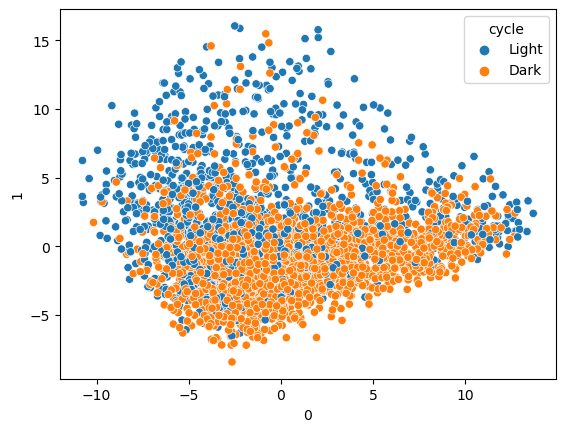

In [19]:
sns.scatterplot(data=dfviz, x=0, y=1, hue='cycle')

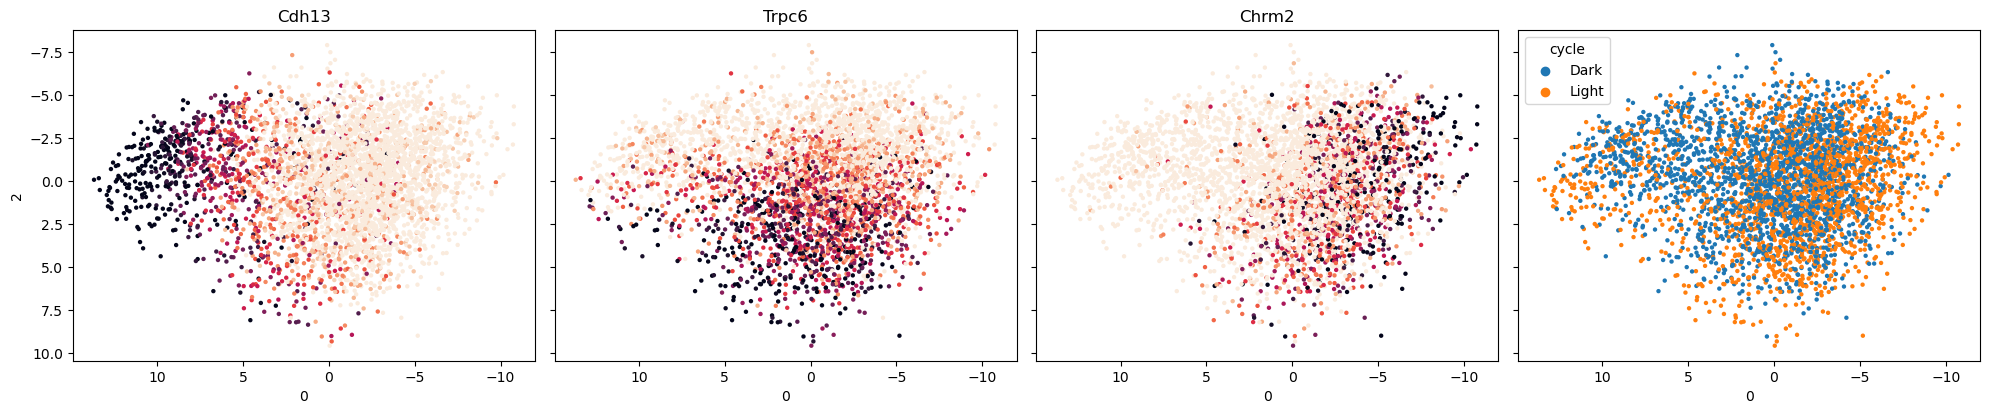

In [20]:

gns = ['Cdh13', 'Sorcs3', 'Chrm2']
gns = ['Cdh13', 'Nptx2', 'Chrm2']
gns = ['Cdh13', 'Trpc6', 'Chrm2']

fig, axs = plt.subplots(1, 4, figsize=(4*5,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=0, y=2, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')

ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=0, y=2, hue='cycle', ax=ax, s=10, edgecolor='none')
ax.set_aspect('equal')

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

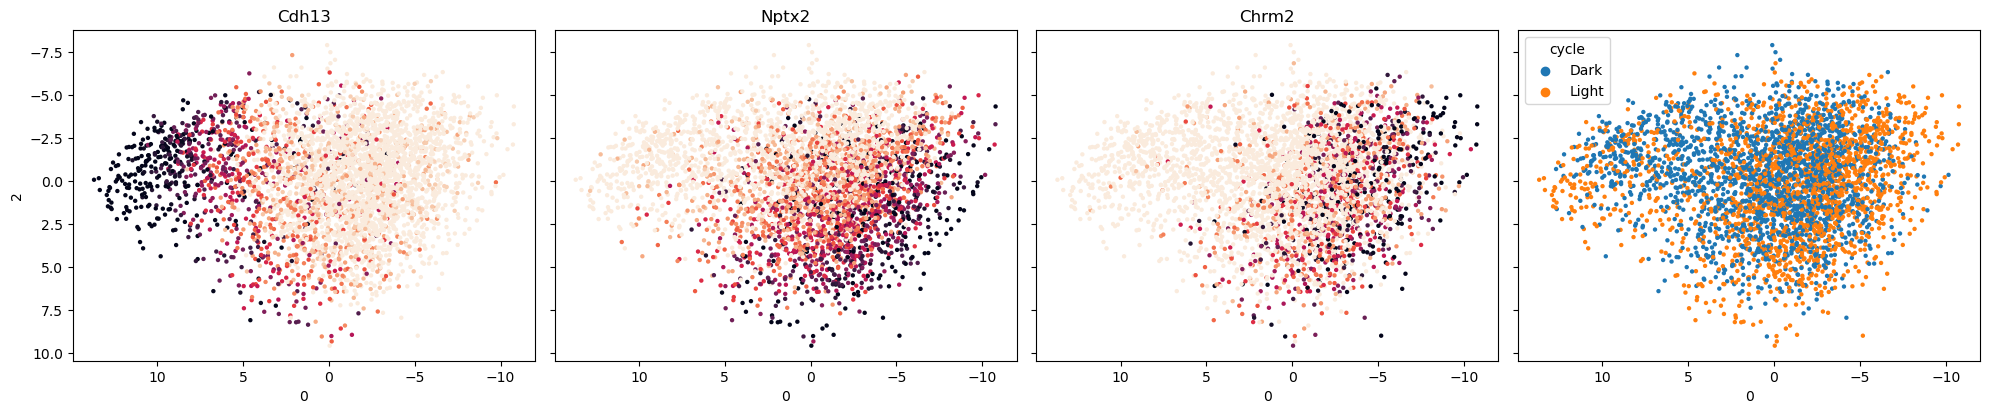

In [21]:

gns = ['Cdh13', 'Sorcs3', 'Chrm2']
gns = ['Cdh13', 'Nptx2', 'Chrm2']

fig, axs = plt.subplots(1, 4, figsize=(4*5,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=0, y=2, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')

ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=0, y=2, hue='cycle', ax=ax, s=10, edgecolor='none')
ax.set_aspect('equal')

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

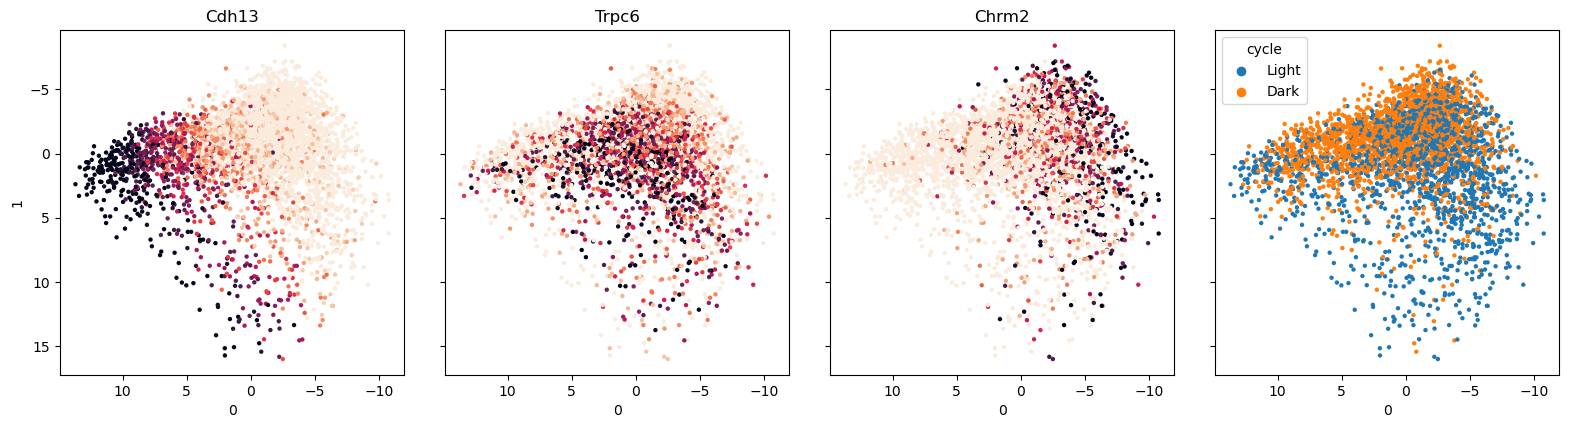

In [22]:

gns = ['Cdh13', 'Sorcs3', 'Chrm2']
gns = ['Cdh13', 'Nptx2', 'Chrm2']
gns = ['Cdh13', 'Trpc6', 'Chrm2']

fig, axs = plt.subplots(1, 4, figsize=(4*4,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=0, y=1, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')

ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=0, y=1, hue='cycle', ax=ax, s=10, edgecolor='none')
ax.set_aspect('equal')

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

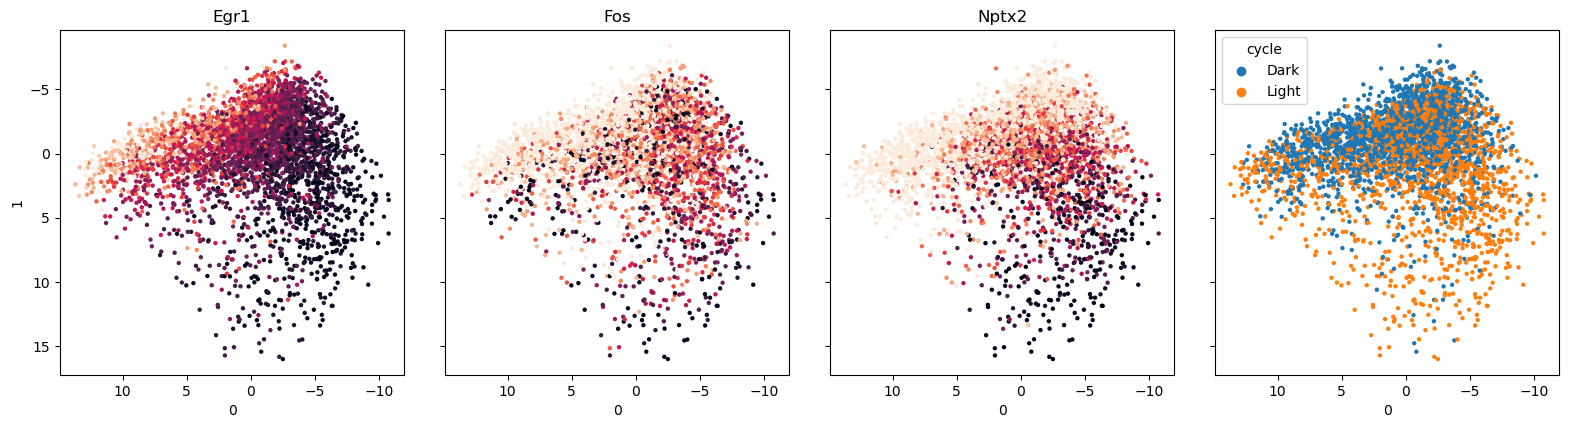

In [23]:


gns = ['Egr1', 'Fos', 'Nptx2']

fig, axs = plt.subplots(1, 4, figsize=(4*4,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=0, y=1, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')

ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=0, y=1, hue='cycle', ax=ax, s=10, edgecolor='none')
ax.set_aspect('equal')

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

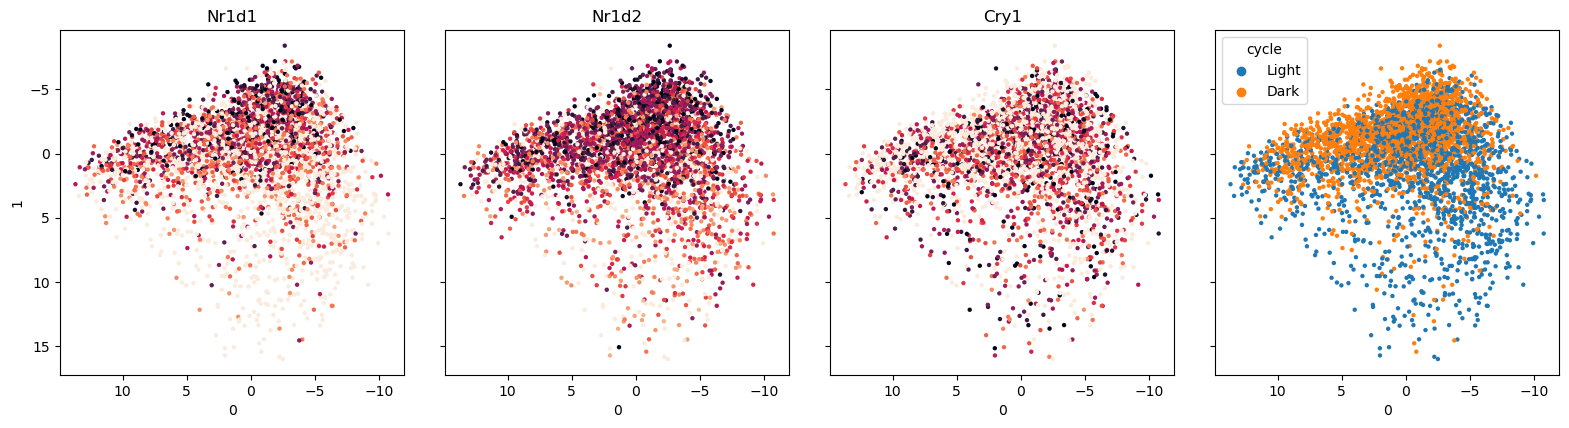

In [24]:
gns = ['Nr1d1', 'Nr1d2', 'Cry1']

fig, axs = plt.subplots(1, 4, figsize=(4*4,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=0, y=1, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')

ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=0, y=1, hue='cycle', ax=ax, s=10, edgecolor='none')
ax.set_aspect('equal')

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

In [25]:
# show two replicates 
# crunch some numbers 
# log1p or zscore? 